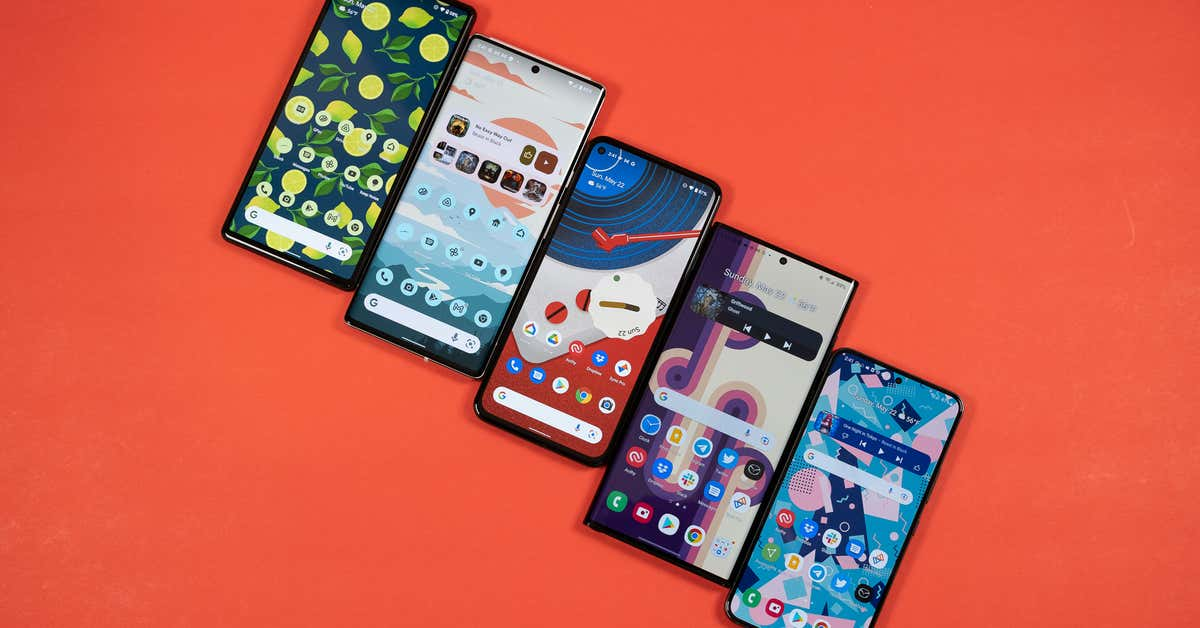

__In this notebook, we are going to build a model which classifes the mobiles into 0 very cheap, 1 cheap, 2  expensive, 3 very expensive<br>
This dataset has some incorrect data which is not real, so i may ignore sth if not i will have to remove them which causes loss information__

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, confusion_matrix, f1_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

__Setting size/style :__

In [ ]:
sns.set_style("darkgrid")
plt.rcParams.update({"font.size" : 12, "axes.labelsize" : 14})

# Read Datasets

In [ ]:
df_train = pd.read_csv("/kaggle/input/mobile-pricing-dataset/train.csv")
df_test = pd.read_csv("/kaggle/input/mobile-pricing-dataset/test.csv")

# Dataset Overview

__Training dataset overview :__

In [ ]:
df_train.head()

In [ ]:
df_train.shape

__Training dataset has 2000 rows and 21 columns__

__Testing dataset overview :__

In [ ]:
df_test.head()

In [ ]:
df_test.shape

__Testing dataset has 1000 rows and 21 columns__

## Dataset Basic Information

__Training dataset basic information :__

In [ ]:
df_train.info()


__Testing dataset basic information :__

In [ ]:
df_test.info()

+ __Conculsion :__
   - Training set :
       - __There is no object column in the training dataset__
       - __The price_range column is the target / dependent variable __ 
   - Testing set :
       - __There is no object column in test dataset__
       - __If the id column acts as an identifier, it has to be removed__

## Numerical Columuns Description

__Training Dataset Numerical Columns Description :__

In [ ]:
df_train.describe(include = "number").T

__Test Dataset Numerical Columns Description :__

In [ ]:
df_test.describe(include = "number").T

## Useful Self-made Functions For Data visualization

In [ ]:
def set_freq_label(ax, fmt = "%1.f" , padding = 0):
    ''' set label for the bars of a barplot '''
    sns.set_style("darkgrid")
    for cont in ax.containers:
        ax.bar_label(cont, fmt = fmt, padding = padding)
# ------------------------------------------------------------------------------------
def plot_unique_freq(df):
    ''' plot a nunique value barplot with bar labels '''
    sns.set_style("darkgrid")
    ax = df.nunique().sort_values().plot.bar(figsize = (16,7), color = "royalblue")
    set_freq_label(ax, fmt = "%1.f", padding = 5)
    plt.xlabel("Columns")
    plt.ylabel("Frequency")
    plt.margins((0.1))
    plt.title("Column Unique Value Counts", size = 20, y = 1.08, fontweight = "bold")
    plt.grid()
    plt.show()

##  Seperate Continuous and Categorical Features

__Plotting the number of feature unique values:__

In [ ]:
ax = df_train.nunique().sort_values().plot.bar(figsize = (16,7), color = "royalblue")
set_freq_label(ax, fmt = "%1.f", padding = 5)
plt.ylabel("Columns")
plt.xlabel("Frequency")
plt.margins(0.1)
plt.title("Training Dataset Unique Values", size = 20, y = 1.05, fontweight = "bold")
plt.tick_params(labelsize = 13)

- __Training :__
  * __The columns from n_cores to Blue and the columns ( ram & int_memory ) <br> are absulote categorical, the others appear to be continuous features in reality__ 
  * __The price_range ( target ) is discrete and multiclass label, it has 4 clasess__ 

###  Categorical Variables

In [ ]:
catg_vars = df_train["price_range,Blue,touch_screen,dual_sim,four_g,three_g,wifi,n_cores,int_memory,ram".split(",")].columns
catg_vars

__Training dataset frequency disturbution of categorical features :__ 

In [ ]:
for col in catg_vars:
    print(df_train[col].value_counts())

+ __The price_range variable (target) is highly balanced__

__Testing dataset frequency disturbution of categorical features :__

In [ ]:
for col in catg_vars.drop("price_range"):
    print(df_train[col].value_counts())

### Numerical & Quantitative Variables

In [ ]:
cont_vars = df_train.drop(catg_vars, axis = 1).columns

In [ ]:
cont_vars

# Correlation Analysis

In [ ]:
sns.set_style("white")
plt.figure(figsize = (20,10))
df_corr = df_train.corr(method = "spearman")
mask = np.triu(np.ones_like(df_corr, dtype = bool))
sns.heatmap(df_corr, annot = True, cmap = "coolwarm", cbar = True, annot_kws = {"size" : 11}, mask = mask)
plt.tick_params(labelsize = 14)
plt.show()

+ __Conculsion :__
    - With the target ( price_range ) :
        * There is a high positive correlation between __ram and price_range ( target ) %92__,<br>
        it is the most important feature in this dataset
        * There is almost a good positive correlation between <br> __px_width/px_hieght/battery_power and the target__
    - With the other features :
        * There is a high positive correlation between __( px_height and px_width )__ as well as <br>
        __( pc with fc )__ and __( sc_w with sc_h )__ and __( four_g with three_g )__

    
    

# Data Preprocessing

## Feature Subset Selection

__The id column in testing set :__

In [ ]:
df_test.id

__The amount of unique values :__

In [ ]:
df_test.id.nunique()

__As a result, it acts as an identifier, the id column has to be removed__

__Removing the id column :__

In [ ]:
df_test = df_test.drop("id", axis = 1)

## Data Cleansing 

In [ ]:
cont_vars

### Training Dataset Outlier Detection

In [ ]:
sns.set_style("darkgrid")
fig = plt.figure(figsize = (16, 12))
for idx, col in enumerate(cont_vars):
    plt.subplot(4,3, idx + 1)
    sns.boxplot(x = "price_range", y = col, data = df_train, palette = "coolwarm")
plt.tight_layout()
plt.show()

+ __Conculsion :__
  - About the fc feature ( Front camera mega pixel ) :
    * it makes sense that in the 0 (very cheap) and 1 (cheap) mobile phones, we do not have <br>
    front camera with higher than almost 13 or 16 mega pixel, so the outliers seem to be noise <br>
    where price_range is 0, 1
  - About the px_height feature ( Pixel Resolution Height ) :
    * the mobile phones which are 0 (very cheap) do not have the resolution height higher than almost 1600<br>
    the outliers in the 0 price_range are noise
  - Absolute noise data : 
    * in the px_height where px_height = 0, the data is noise : <br>
    all the mobile phones have screen and a screen needs pixel to show
    * in the sc_w where sc_w = 0, the data is noise : <br>
    we do not have any mobile phone with zero screen width
    


__Getting the specified noise in above conculsion:__

In [ ]:
list_index = []
outlier_info = []
for col in ["fc", "px_height"]:
    indexes = []
    for target_class in df_train.price_range.unique():
        if (col == "fc"):
            if (target_class in [2,3]):
                continue
        else :
            if (target_class != 0) :
                continue
        df = df_train[df_train.price_range == target_class][col]
        Q1 = df.quantile(.25)
        Q3 = df.quantile(.75)
        IQR = Q3 - Q1
        minimum = Q1 - (1.5 * IQR)
        maximum = Q3 + (1.5 * IQR)
        indexes.extend(df[(df < minimum) | (df > maximum)].index)
        list_index.extend(indexes)
    outlier_info.append({"Feature" : col, "Outlier_index" : indexes,
                         "Outlier%" : (len(indexes) / df_train.shape[0]) * 100})
outlier_info = pd.DataFrame(outlier_info)

__These indexes must be removed :__

In [ ]:
outlier_info

In [ ]:
outlier_info.plot.barh(x = "Feature", y = "Outlier%", color = "royalblue")
plt.show()

### Absolute noise data or incorrect data

__The px_height feature :__

In [ ]:
df_train[df_train.px_height == 0]

In [ ]:
px_height_noiseIndex_train = df_train[df_train.px_height == 0].index

In [ ]:
px_height_noiseIndex_train

__The sc_w feature :__

In [ ]:
sc_w_noise_train = df_train[df_train.sc_w == 0].sc_w.values

### Testing Dataset Outlier detection

In [ ]:
sns.set_style("darkgrid")
fig = plt.figure(figsize = (16, 11))
for idx, col in enumerate(cont_vars):
    plt.subplot(4,3, idx + 1)
    sns.boxplot(x = col, data = df_test, palette = "coolwarm")
plt.tight_layout()
plt.show()

+ __About the px_height like in the training analysis, we have incorrect data where px_height = 0 as well as <br>
in the sc_w where sc_w = 0__

__The px_height feature :__

In [ ]:
px_height_noiseIndex_test = df_test[df_test.px_height == 0].index

__The sc_w feature :__

In [ ]:
sc_w_noise_test = df_test[df_test.sc_w == 0].sc_w.values

##  Discover Missing Value

__Training Dataset :__

In [ ]:
df_train.isna().sum()

__There is no missing data in training dataset__

__Testing Dataset :__

In [ ]:
df_test.isna().sum()

__There is no missing data in testing dataset__

## Discover Duplicates

__Training Dataset :__

In [ ]:
df_train.duplicated().sum()

__There is no duplicated rows in training dataset__

__Testing dataset :__

In [ ]:
df_test.duplicated().sum()

__There is no duplicated rows in testing dataset__

## Dealing With Outlier Data

### Training Dataset

In [ ]:
outlier_info

__Removing the outliers :__

In [ ]:
df_train.drop(outlier_info["Outlier_index"][0], inplace = True)

In [ ]:
df_train.drop(outlier_info["Outlier_index"][1],inplace = True)

In [ ]:
px_height_noiseIndex_train

In [ ]:
df_train.drop(px_height_noiseIndex_train, inplace = True)

__Replacing the data where sc_w = 0 with its mean :__

In [ ]:
df_train["sc_w"].replace(sc_w_noise_train, round(df_train.sc_w.mean()), inplace = True)

### Testing Dataset

In [ ]:
px_height_noiseIndex_test

__Removing the outliers :__

In [ ]:
df_test.drop(px_height_noiseIndex_test, inplace = True)

__Replacing the data where sc_w = 0 with its mean :__

In [ ]:
df_test.sc_w.replace(sc_w_noise_test, round(df_test.sc_w.mean()), inplace = True)

#  EDA

##  Target Vs Continuous Features Analysis

In [ ]:
cont_vars

In [ ]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(11, 2, figsize = (16, 31), gridspec_kw = {"width_ratios" : [1, 2]})

i = 0
for idx, col in enumerate(cont_vars):
    
    sns.boxplot(y = col, x = "price_range", data = df_train, palette = "coolwarm", ax = ax[idx,0])
    
    sns.kdeplot(x = col, data = df_train, palette = "coolwarm", ax = ax[idx, 1], hue = "price_range",
                      fill = True)
    
plt.suptitle('Numerical Features vs Target Distribution', fontsize=22, y = 1.005)
plt.tight_layout()
plt.show()

+ __Analysis :__
  - battery_power :
      * it has almost a normal disturbution
      * it has a great impact on the target because when switching on <br>
      the target clasess , the medians in boxplot is highly changed
      * it says that the more expensive the mobile phones, the more battery power they have
  - clock_speed : 
      * it has almost a normal disturbution
      * in terms of its boxplot, the median in class zero (very cheap mobile phone ) <br>
      is higher than other means that very cheap mobile phones have higher clock speed which is unsual<br>
      if look closer to the densities we realize that the clasess 2,3 are higher than others which means<br>
      the expensive and very expensive mobiles have higher clock speed
  - fc (front camera megapixel) :
      * it has a positive skew disturbution
      * it has a little impact on the target because of the densities of clasess change a little when switching <br>
      on the target classes
      * it can almost say that the more expensive the mobile phones, the more front camera capacity they have 
  - m_dep :
      * it has almost a normal disturbution
      * it does not have any impact on the target, bacause in reality, we have both low and high depth for any kind of mobiles
  - mobile_wt : 
      * it has almost a normal disturbution
      * it has a little impact on the target because when switching on the clasess , the medians in boxplot change a little
      * it says that approximately the more expensive the mobile phones, the less weight they have 
  - pc ( primary camera megapixel ) :
      * it has almost a normal disturbution
      * it has a little impact on the target because when switching on the clasess, the medians in boxplot change a little
      * it says that approximately the more expensive the mobile phones, the more main camera capacity they have
  - px_height :
      * it has a positive skew disturbution
      * it has a great impact on the target because when switching on <br>
      the target clasess , the medians in boxplot is highly changed
      * it says that the more expensive the mobile phones, the more pixels of screen's height they have
  - px_width : 
      * it has almost a normal disturbution
      * it has a great impact on the target because when switching on <br>
      the target clasess , the medians in boxplot is highly changed
      * it says that the more expensive the mobile phones, the more pixels of screen's width they have
  - talk_time :
      * it has almost a normal disturbution
      * it has a little impact on the target because when switching on <br>
      the target clasess , the medians in boxplot is not highly changed
      * it can almost say that the more expensive the mobile phones, the more time their batteries can last
  - The most important __continuous__ features on target : 
      * battery_power
      * px_height
      * px_width
  - __Approximately, 90 percent of the features have normal distribution and <br>
  the others have skew distribution__


## Target Vs Categorical Features Analysis

In [ ]:
catg_vars.drop(["ram", "int_memory", "price_range"])

In [ ]:
sns.set_style("darkgrid")
fig = plt.figure(figsize = (16, 30))
i = 0
for idx, col in enumerate(catg_vars.drop(["ram", "int_memory", "price_range"])):
    plt.subplot(7,2,  i + 1)
    value_counts = df_train[col].value_counts()
    plt.pie(value_counts.values , labels = value_counts.keys(), autopct = "%.2f%%", textprops={'fontsize':14},
           colors = sns.color_palette("Set2"), pctdistance = 0.7)
    hole = plt.Circle((0, 0), 0.45, facecolor='white')
    plt.gcf().gca().add_artist(hole)
    plt.legend(loc = 4)
    
    plt.subplot(7,2,  i + 2)
    ax = sns.countplot(x = col, data = df_train, palette = "coolwarm", hue = "price_range", )
    set_freq_label(ax)
    plt.legend(loc = 4)
    plt.margins((0.1))
    i += 2
plt.suptitle("Density Disturbution Of Categorical Features Vs Target", y = 1, x = 0.55, size = 20,
    fontweight = "bold")
plt.tight_layout()
plt.show()

### ram and int_memory  <br>
   - __as a result of these features have continuous disturbution but they are categorical, i use kdeplot to analyze them__

In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize = (16,4))
plt.subplot(1,2, 1)
sns.kdeplot(x = "ram", data = df_train, hue = "price_range", fill = True, palette = "coolwarm")
plt.subplot(1,2, 2)
sns.kdeplot(x = "int_memory", data = df_train, hue = "price_range", fill = True, palette = "coolwarm")
plt.show()

### Target Disturbution

In [ ]:
target_value_counts = df_train.price_range.value_counts().sort_index()
fig = px.pie(values = target_value_counts.values, 
             labels = np.array(["Very Cheap", "Cheap", "Expensive", "Very expensive"]),
             names = np.array(["Very Cheap", "Cheap", "Expensive", "Very expensive"]), title = "Target Disturbution",)
fig.show()

__The target ( price_range ) is highly balanced , which is great__

+ __Consulsion :__
    - Blue :
        * it is balanced
        * it has almost a good impact on the target, because when switching on the classes, <br>the bars' order of the target clasess is changed
        * a mobile with bluetooth is more expensive
    - touch screen :
        * it is balanced
        * it has almost a good impact on the target, because when switching on the classes, <br>the bars' order of the target clasess is changed
         * a mobile with touch screen is more expensive
    - dual sim : 
         * it is balanced
         * it does not have a good impact on the target, because It shows a similar behavior in <br> all cost types of mobile phones
    - four_g :
         * it is balanced
         * it has almost a good impact on the target, because when switching on the classes, <br>the bars' order of the target clasess is changed
         * a mobile with four_g attribue is more expensive than the others
    - three_g :
        * it is imbalanced
        * it has almost a good impact on the target, because when switching on the classes, <br>the bars' order of the target clasess is changed
        * a mobile with three_g attribue is more expensive than the others
    - wifi :
        * it is balanced
        * it has almost a good impact on the target, because when switching on the classes, <br>the bars' order of the target clasess is changed
        * a mobile with wifi attribue is more expensive than the others
    - n_cores :
        * it is balanced
        * it has almost a good impact on the target, because when switching on the classes, <br>the bars' order of the target clasess is changed
        * a mobile with more cores is much more expensive than the others
    - __ram :__
        * it has the greatest impact on the target in this dataset, as shown the disturbutions are highly changed <br> when switching on the target classes
        * a mobile phone with more ram is more expensive than the others
    - int_memory :
        * it does not have a good impact on the target
        * it can almost say that more int_memory more expensive mobile
    - Most important features :
        * ram ( the most important feature in this dataset )
        * three_g
        * wifi
        * n_cores

# Model Building With DTs, SVM, RF

__Point : The dataset is balanced__

In [ ]:
df_train.head()

## Self-made Functions For Models

In [ ]:
def hyperparameter_tuning (model, params, X_train, y_train):
    
    kfold = StratifiedKFold(shuffle = True, random_state = 0)
    grid_model = GridSearchCV(model, param_grid = params, cv = kfold, scoring = "accuracy", n_jobs = -1)
    grid_model.fit(X_train, y_train)
    print("Best  hyperparameters : \n", grid_model.best_params_,"*" *30, 
         "Best accuracy_score : \n", grid_model.best_score_, sep = "\n")
    return grid_model.best_estimator_

# ------------------------------------------------------------------------------------------------------------

def model_evaluation(model, X_train, X_test, y_train, y_test, model_name) :
    
    sns.set_style("darkgrid")
    train_test_scores = []
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    cm = confusion_matrix(y_test, y_pred_test)
    train_test_score = pd.DataFrame({"Train_score" : [model.score(X_train, y_train)],
                                    "Test_score" : [model.score(X_test, y_test)]}, index = [model_name])
    print("Test result".center(60, "*"),classification_report(y_test, y_pred_test),
         sep = "\n")
    print("Train result".center(60, "*"), classification_report(y_train, y_pred_train),
         sep = "\n")
    print("*" * 60)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=80)
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax = ax1)
    ax1.grid()
    
    
    train_test_score.plot.barh(ax = ax2, cmap = "coolwarm")
    set_freq_label(ax2, "%.2f")
    plt.margins((0.09))
    plt.tight_layout()
    return train_test_score

# Decision Tree

__Train test splitting :__

In [ ]:
X, y = df_train.drop("price_range", axis = 1), df_train.price_range

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state = 0)

In [ ]:
print("*" * 30,f"X_train shape : {X_train.shape}", 
     f"X_test shape : {X_test.shape}",
     f"y_train shape : {y_train.shape}",
     f"y_test shape : {y_test.shape}",
      "*" * 30, sep = "\n")

__Hyperparameter tuning :__

In [ ]:
tree_pipline = make_pipeline(StandardScaler(), DecisionTreeClassifier())

params = {
    'decisiontreeclassifier__max_depth': [ 5, 10, 20, 25, 30],
    'decisiontreeclassifier__min_samples_leaf': [5, 10, 20, 50, 100, 150],
    'decisiontreeclassifier__min_samples_split' : [5, 10, 20, 50, 100, 150]}
grid_model_dts = hyperparameter_tuning(tree_pipline, params, X_train, y_train)

In [ ]:
grid_model_dts

__Evaluation :__

In [ ]:
train_test_score_dts = model_evaluation(grid_model_dts, X_train, X_test, y_train, y_test, "DTs")

# RandomForest (RL)

__Train test splitting :__

In [ ]:
X, y = df_train.drop("price_range", axis = 1), df_train.price_range
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state = 0)

__Hyperparameter tuning :__

In [ ]:
rl =  make_pipeline(StandardScaler(), RandomForestClassifier(n_jobs = -1))
params = {
    'randomforestclassifier__n_estimators': [10,20,30,40], 
    'randomforestclassifier__max_depth': np.arange(5, 10),
    'randomforestclassifier__min_samples_leaf': [1, 2, 3],
    'randomforestclassifier__min_samples_split' : np.arange(2, 10)
    }
grid_model_rl = hyperparameter_tuning(rl, params, X_train, y_train)

__Evaluation :__

In [ ]:
train_test_score_rl = model_evaluation(grid_model_rl,X_train, X_test, y_train, y_test, "Random Forest")

# Support Vector Machine (SVM)

__Point : as default the SVM model works on multiclass target__

__Tran test splitting :__

In [ ]:
X, y = df_train.drop("price_range", axis = 1), df_train.price_range
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .25, random_state = 0)

__Scaling :__

In [ ]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = scaler.feature_names_in_)
X_test = pd.DataFrame(scaler.transform(X_test), columns = scaler.feature_names_in_)

__As svm takes a long time for hyperparamter tuning, i used all other kernel for svm then linear kernel gave a <br> better result than others, so i do not use other kernel here to save time__

__Hyperparameter tuning :__

In [ ]:
svm =  SVC()
params = {'kernel': ['linear'], 'C': [0.1,0.3, 1,2,2.5, 3,3.5, 4, 10]}
grid_model_svm = hyperparameter_tuning(svm, params, X_train, y_train)

__Evaluation :__

In [ ]:
train_test_score_svm = model_evaluation(grid_model_svm, X_train, X_test, y_train, y_test, "SVM")

# Models Comparison

__Concatinating the results of all the three model :__

In [ ]:
models_comparison = pd.concat([train_test_score_dts, train_test_score_rl, train_test_score_svm])

__Plotting the result barplot :__

In [ ]:
ax = models_comparison.plot(kind = "barh", cmap = "coolwarm", figsize = (14,8))
plt.axvline(x = .8, ls = "--", color = "y")
plt.title("Model Comparison", fontweight = "bold", size = 23, y = 1.06)
set_freq_label(ax, fmt = "%.2f%%")

+ __Conculsion :__
    - As the dataset is highly balanced, comapring just the accuracy score can show how well the models work
    - Here, the plot shows that the svm is just fit and has as great score on the test data and train data, <br>
    but the others are showing kind of overfitting which is terrible
    - __The SVM model is selected as the final model__

# 🏆 Acurracy 96% 

----

# ⭕️ Final Model Testing On The Unknown Data 

__Train test splitting :__

In [ ]:
X, y = df_train.drop("price_range", axis = 1), df_train.price_range

__Model building :__

In [ ]:
Final_model = make_pipeline(StandardScaler(), SVC())
Final_model[1].set_params(**grid_model_svm.get_params())

In [ ]:
Final_model.fit(X, y)

## Test dataset

In [ ]:
df_test.head()

In [ ]:
y_final_pred = Final_model.predict(df_test)

__Showing the predicted test target frequency :__

In [ ]:
final_prediction = pd.Series(y_final_pred)
ax = final_prediction.value_counts().plot.bar(figsize = (12,6), color = "royalblue")
plt.title("Predicted Test Target Frequency",  fontweight = "bold", size = 23, y = 1.06)
set_freq_label(ax)